In [93]:
import pandas as pd
df =  pd.read_csv("../data/AB_NYC_2019.csv")


In [94]:
df = df.drop(columns = ["id","host_id","host_name"]) #drop columns id , host id, host name because not use for Y^


In [95]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 13 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   name                            48879 non-null  str    
 1   neighbourhood_group             48895 non-null  str    
 2   neighbourhood                   48895 non-null  str    
 3   latitude                        48895 non-null  float64
 4   longitude                       48895 non-null  float64
 5   room_type                       48895 non-null  str    
 6   price                           48895 non-null  int64  
 7   minimum_nights                  48895 non-null  int64  
 8   number_of_reviews               48895 non-null  int64  
 9   last_review                     38843 non-null  str    
 10  reviews_per_month               38843 non-null  float64
 11  calculated_host_listings_count  48895 non-null  int64  
 12  availability_365                48895 non-n

In [96]:
print("Missing name before:", df["name"].isnull().sum())

Missing name before: 16


In [97]:
df = df.dropna(subset=["name"])

In [98]:
df.info()

<class 'pandas.DataFrame'>
Index: 48879 entries, 0 to 48894
Data columns (total 13 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   name                            48879 non-null  str    
 1   neighbourhood_group             48879 non-null  str    
 2   neighbourhood                   48879 non-null  str    
 3   latitude                        48879 non-null  float64
 4   longitude                       48879 non-null  float64
 5   room_type                       48879 non-null  str    
 6   price                           48879 non-null  int64  
 7   minimum_nights                  48879 non-null  int64  
 8   number_of_reviews               48879 non-null  int64  
 9   last_review                     38837 non-null  str    
 10  reviews_per_month               38837 non-null  float64
 11  calculated_host_listings_count  48879 non-null  int64  
 12  availability_365                48879 non-null  

In [99]:
missing = pd.DataFrame({ 
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum() / len(df)) * 100
})

missing = missing[missing["Missing Values"] > 0]

missing # we are drop the name column in null rows and host_name column is drop 

,Missing Values,Percentage
last_review,10042,20.54461
reviews_per_month,10042,20.54461


In [100]:
# Replace null values in reviews_per_month with 0
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)
print("Missing values:",
      df["reviews_per_month"].isnull().sum())

Missing values: 0


In [101]:
df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')

df['review_year'] = df['last_review'].dt.year
df['review_month'] = df['last_review'].dt.month
df['review_dayofweek'] = df['last_review'].dt.dayofweek

In [102]:
reference_date = df['last_review'].max()

df['days_since_review'] = (
    reference_date - df['last_review']
).dt.days

In [67]:
df.info()

<class 'pandas.DataFrame'>
Index: 48879 entries, 0 to 48894
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   name                            48879 non-null  str           
 1   neighbourhood_group             48879 non-null  str           
 2   neighbourhood                   48879 non-null  str           
 3   latitude                        48879 non-null  float64       
 4   longitude                       48879 non-null  float64       
 5   room_type                       48879 non-null  str           
 6   price                           48879 non-null  int64         
 7   minimum_nights                  48879 non-null  int64         
 8   number_of_reviews               48879 non-null  int64         
 9   last_review                     38837 non-null  datetime64[us]
 10  reviews_per_month               48879 non-null  float64       
 11  calculated_host_li

In [103]:
# Replace null values in reviews_per_month with 0
df["review_year"] = df["review_year"].fillna(0)
print("Missing values:",
      df["review_year"].isnull().sum())

Missing values: 0


In [104]:
# Replace null values in reviews_per_month with 0
df["review_month"] = df["review_month"].fillna(0)
print("Missing values:",
      df["review_month"].isnull().sum())
# Replace null values in reviews_per_month with 0
df["review_dayofweek"] = df["review_dayofweek"].fillna(0)
print("Missing values:",
      df["review_dayofweek"].isnull().sum())
# Replace null values in reviews_per_month with 0
df["days_since_review"] = df["days_since_review"].fillna(0)
print("Missing values:",
      df["days_since_review"].isnull().sum())

Missing values: 0
Missing values: 0
Missing values: 0


In [105]:
df.info()

<class 'pandas.DataFrame'>
Index: 48879 entries, 0 to 48894
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   name                            48879 non-null  str           
 1   neighbourhood_group             48879 non-null  str           
 2   neighbourhood                   48879 non-null  str           
 3   latitude                        48879 non-null  float64       
 4   longitude                       48879 non-null  float64       
 5   room_type                       48879 non-null  str           
 6   price                           48879 non-null  int64         
 7   minimum_nights                  48879 non-null  int64         
 8   number_of_reviews               48879 non-null  int64         
 9   last_review                     38837 non-null  datetime64[us]
 10  reviews_per_month               48879 non-null  float64       
 11  calculated_host_li

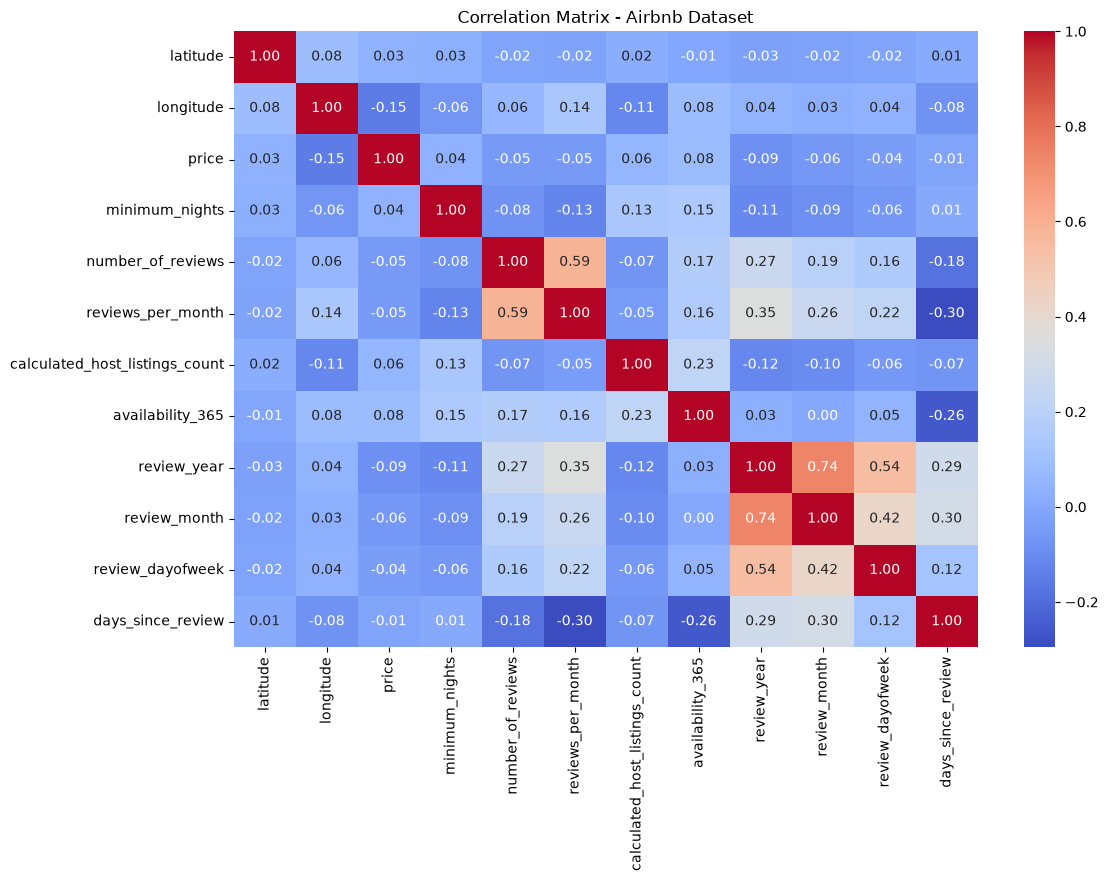

In [106]:
import matplotlib.pyplot as plt
import seaborn as sns
correlation_matrix = df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix - Airbnb Dataset")
plt.show()

In [107]:
# Check number of zero-price rows
print("Rows with price = 0:", (df["price"] == 0).sum())

# Remove zero-price rows
df = df[df["price"] > 0].copy()

print("New shape:", df.shape)

Rows with price = 0: 11
New shape: (48868, 17)


In [108]:
df = df.drop(columns = ["name"])

Create geographic clusters

In [109]:
from sklearn.cluster import KMeans

# Use latitude and longitude for geographic clustering
geo_data = df[['latitude', 'longitude']]

kmeans = KMeans(
    n_clusters=25,
    random_state=42,
    n_init=10
)

df['geo_cluster'] = kmeans.fit_predict(geo_data)

df[['latitude', 'longitude', 'geo_cluster']].head()

,latitude,longitude,geo_cluster
0,40.64749,-73.97237,12
1,40.75362,-73.98377,13
2,40.80902,-73.94190,0
3,40.68514,-73.95976,16
4,40.79851,-73.94399,0


In [74]:
df.drop(
    columns=['neighbourhood_group', 'neighbourhood'],
    inplace=True
)

In [75]:
df.info()

<class 'pandas.DataFrame'>
Index: 48868 entries, 0 to 48894
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   latitude                        48868 non-null  float64       
 1   longitude                       48868 non-null  float64       
 2   room_type                       48868 non-null  str           
 3   price                           48868 non-null  int64         
 4   minimum_nights                  48868 non-null  int64         
 5   number_of_reviews               48868 non-null  int64         
 6   last_review                     38827 non-null  datetime64[us]
 7   reviews_per_month               48868 non-null  float64       
 8   calculated_host_listings_count  48868 non-null  int64         
 9   availability_365                48868 non-null  int64         
 10  review_year                     48868 non-null  float64       
 11  review_month      

In [110]:
df['geo_distance'] = kmeans.transform(
    geo_data
).min(axis=1)

Create room_geo_cluster

In [111]:
from sklearn.cluster import KMeans
import pandas as pd

# Number of geographic clusters for each room type
n_clusters = 5

df['room_geo_cluster'] = -1

for room in df['room_type'].unique():

    mask = df['room_type'] == room

    coordinates = df.loc[mask, ['latitude', 'longitude']]

    kmeans = KMeans(
        n_clusters=n_clusters,
        random_state=42,
        n_init=10
    )

    df.loc[mask, 'room_geo_cluster'] = kmeans.fit_predict(coordinates)

df[['room_type', 'latitude', 'longitude', 'room_geo_cluster']].head(20)

,room_type,latitude,longitude,room_geo_cluster
0,Private room,40.64749,-73.97237,0
1,Entire home/apt,40.75362,-73.98377,0
2,Private room,40.80902,-73.94190,3
3,Entire home/apt,40.68514,-73.95976,1
4,Entire home/apt,40.79851,-73.94399,4
5,Entire home/apt,40.74767,-73.97500,0
6,Private room,40.68688,-73.95596,2
7,Private room,40.76489,-73.98493,1
8,Private room,40.80178,-73.96723,3
9,Entire home/apt,40.71344,-73.99037,0


In [78]:
df.drop(
    columns=['room_type','last_review'],
    inplace=True
)

In [79]:
df.info()

<class 'pandas.DataFrame'>
Index: 48868 entries, 0 to 48894
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   latitude                        48868 non-null  float64
 1   longitude                       48868 non-null  float64
 2   price                           48868 non-null  int64  
 3   minimum_nights                  48868 non-null  int64  
 4   number_of_reviews               48868 non-null  int64  
 5   reviews_per_month               48868 non-null  float64
 6   calculated_host_listings_count  48868 non-null  int64  
 7   availability_365                48868 non-null  int64  
 8   review_year                     48868 non-null  float64
 9   review_month                    48868 non-null  float64
 10  review_dayofweek                48868 non-null  float64
 11  days_since_review               48868 non-null  float64
 12  geo_cluster                     48868 non-null  

In [112]:
!pip install lightgbm
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from lightgbm import LGBMRegressor


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


#price capping\
price_cap = df["price"].quantile(0.99)

df_model = df[df["price"] <= price_cap].copy()

print("Price cap:", price_cap)
print("Rows before:", len(df))
print("Rows after :", len(df_model))
print("Data retained:", round(len(df_model) / len(df) * 100, 2), "%")

#Separate X and y
X = df_model.drop(columns=["price"])
y = df_model["price"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

X_test, X_unseen, y_test, y_unseen = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42
)

print("Train :", X_train.shape)
print("Val   :", X_val.shape)
print("Test  :", X_test.shape)
print("Unseen:", X_unseen.shape)

Geographic clustering

kmeans = KMeans(
    n_clusters=25,
    random_state=42,
    n_init=10
)

X_train = X_train.copy()
X_val = X_val.copy()
X_test = X_test.copy()
X_unseen = X_unseen.copy()

X_train["geo_cluster"] = kmeans.fit_predict(
    X_train[["latitude", "longitude"]]
)

X_val["geo_cluster"] = kmeans.predict(
    X_val[["latitude", "longitude"]]
)

X_test["geo_cluster"] = kmeans.predict(
    X_test[["latitude", "longitude"]]
)

X_unseen["geo_cluster"] = kmeans.predict(
    X_unseen[["latitude", "longitude"]]
)

X_train[
    ["latitude", "longitude", "geo_cluster"]
].head()

X_train["geo_distance"] = kmeans.transform(
    X_train[["latitude", "longitude"]]
).min(axis=1)

X_val["geo_distance"] = kmeans.transform(
    X_val[["latitude", "longitude"]]
).min(axis=1)

X_test["geo_distance"] = kmeans.transform(
    X_test[["latitude", "longitude"]]
).min(axis=1)

X_unseen["geo_distance"] = kmeans.transform(
    X_unseen[["latitude", "longitude"]]
).min(axis=1)

for data in [X_train, X_val, X_test, X_unseen]:
    data["room_geo"] = (
        data["room_type"].astype(str)
        + "_"
        + data["geo_cluster"].astype(str)
    )

for data in [X_train, X_val, X_test, X_unseen]:
    data.drop(
        columns=["neighbourhood"],
        inplace=True
    )

numeric_features = [
    "latitude",
    "longitude",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
    "review_year",
    "review_month",
    "review_dayofweek",
    "days_since_review",
    "geo_cluster",
    "geo_distance"
]

categorical_features = [
    "neighbourhood_group",
    "room_type",
    "room_geo"
]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        drop="first"
    ))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

lgbm_model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=8,
    num_leaves=31,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", lgbm_model)
])

pipeline.fit(
    X_train,
    np.log1p(y_train)
)

def predict_price(model, X):
    return np.expm1(model.predict(X))

train_pred = predict_price(pipeline, X_train)

print("TRAIN")
print("MAE :", round(
    mean_absolute_error(y_train, train_pred), 2
))

print("RMSE:", round(
    np.sqrt(mean_squared_error(y_train, train_pred)), 2
))

print("R²  :", round(
    r2_score(y_train, train_pred), 4
))

val_pred = predict_price(pipeline, X_val)

print("VALIDATION")
print("MAE :", round(
    mean_absolute_error(y_val, val_pred), 2
))

print("RMSE:", round(
    np.sqrt(mean_squared_error(y_val, val_pred)), 2
))

print("R²  :", round(
    r2_score(y_val, val_pred), 4
))

test_pred = predict_price(pipeline, X_test)

print("TEST")
print("MAE :", round(
    mean_absolute_error(y_test, test_pred), 2
))

print("RMSE:", round(
    np.sqrt(mean_squared_error(y_test, test_pred)), 2
))

print("R²  :", round(
    r2_score(y_test, test_pred), 4
))

unseen_pred = predict_price(pipeline, X_unseen)

print("UNSEEN")
print("MAE :", round(
    mean_absolute_error(y_unseen, unseen_pred), 2
))

print("RMSE:", round(
    np.sqrt(mean_squared_error(y_unseen, unseen_pred)), 2
))

print("R²  :", round(
    r2_score(y_unseen, unseen_pred), 4
))

In [ ]:
#price capping 97.0%
#price capping\
price_cap = df["price"].quantile(0.99)

df_model2 = df[df["price"] <= price_cap].copy()

print("Price cap:", price_cap)
print("Rows before:", len(df))
print("Rows after :", len(df_model))
print("Data retained:", round(len(df_model) / len(df) * 100, 2), "%")

In [331]:
#Separate X and y
X = df_model2.drop(columns=["price"])
y = df_model2["price"]

In [332]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

In [333]:
X_test, X_unseen, y_test, y_unseen = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

In [334]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42
)

In [335]:
print("Train :", X_train.shape)
print("Val   :", X_val.shape)
print("Test  :", X_test.shape)
print("Unseen:", X_unseen.shape)

Train : (27100, 18)
Val   : (6775, 18)
Test  : (7259, 18)
Unseen: (7260, 18)


In [336]:
kmeans = KMeans(
    n_clusters=10,#change the 25 to 10 in unseen dataset 49.61 % and 54.61%
    random_state=42,
    n_init=10
)

X_train = X_train.copy()
X_val = X_val.copy()
X_test = X_test.copy()
X_unseen = X_unseen.copy()

X_train["geo_cluster"] = kmeans.fit_predict(
    X_train[["latitude", "longitude"]]
)

X_val["geo_cluster"] = kmeans.predict(
    X_val[["latitude", "longitude"]]
)

X_test["geo_cluster"] = kmeans.predict(
    X_test[["latitude", "longitude"]]
)

X_unseen["geo_cluster"] = kmeans.predict(
    X_unseen[["latitude", "longitude"]]
)

In [337]:
X_train[
    ["latitude", "longitude", "geo_cluster"]
].head()

,latitude,longitude,geo_cluster
46215,40.70797,-74.00534,5
9647,40.72920,-74.00209,5
25296,40.75500,-73.82333,4
1485,40.74272,-74.00309,5
48519,40.71918,-74.00786,5


In [338]:
X_train["geo_distance"] = kmeans.transform(
    X_train[["latitude", "longitude"]]
).min(axis=1)

X_val["geo_distance"] = kmeans.transform(
    X_val[["latitude", "longitude"]]
).min(axis=1)

X_test["geo_distance"] = kmeans.transform(
    X_test[["latitude", "longitude"]]
).min(axis=1)

X_unseen["geo_distance"] = kmeans.transform(
    X_unseen[["latitude", "longitude"]]
).min(axis=1)

In [339]:
for data in [X_train, X_val, X_test, X_unseen]:
    data["room_geo"] = (
        data["room_type"].astype(str)
        + "_"
        + data["geo_cluster"].astype(str)
    )

In [340]:
for data in [X_train, X_val, X_test, X_unseen]:
    data.drop(
        columns=["neighbourhood"],
        inplace=True
    )

In [341]:
numeric_features = [
    "latitude",
    "longitude",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
    "review_year",
    "review_month",
    "review_dayofweek",
    "days_since_review",
    "geo_cluster",
    "geo_distance"
]

categorical_features = [
    "neighbourhood_group",
    "room_type",
    "room_geo"
]

In [342]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        drop="first"
    ))
])

In [343]:
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [344]:
lgbm_model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=8,
    num_leaves=31,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

In [345]:
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", lgbm_model)
])

In [346]:
pipeline.fit(
    X_train,
    np.log1p(y_train)
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](18,)","['neighbourhood_group','latitude','longitude',...,'geo_distance', 'room_geo_cluster','room_geo']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,18
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed throug

In [347]:
def predict_price(model, X):
    return np.expm1(model.predict(X))

In [348]:
train_pred = predict_price(pipeline, X_train)

print("TRAIN")
print("MAE :", round(
    mean_absolute_error(y_train, train_pred), 2
))

print("RMSE:", round(
    np.sqrt(mean_squared_error(y_train, train_pred)), 2
))

print("R²  :", round(
    r2_score(y_train, train_pred), 4
))

TRAIN
MAE : 39.49
RMSE: 70.86
R²  : 0.5345


In [349]:
val_pred = predict_price(pipeline, X_val)

print("VALIDATION")
print("MAE :", round(
    mean_absolute_error(y_val, val_pred), 2
))

print("RMSE:", round(
    np.sqrt(mean_squared_error(y_val, val_pred)), 2
))

print("R²  :", round(
    r2_score(y_val, val_pred), 4
))

VALIDATION
MAE : 42.23
RMSE: 73.5
R²  : 0.4865


In [350]:
test_pred = predict_price(pipeline, X_test)

print("TEST")
print("MAE :", round(
    mean_absolute_error(y_test, test_pred), 2
))

print("RMSE:", round(
    np.sqrt(mean_squared_error(y_test, test_pred)), 2
))

print("R²  :", round(
    r2_score(y_test, test_pred), 4
))

TEST
MAE : 42.53
RMSE: 74.86
R²  : 0.4825


In [351]:
unseen_pred = predict_price(pipeline, X_unseen)

print("UNSEEN")
print("MAE :", round(
    mean_absolute_error(y_unseen, unseen_pred), 2
))

print("RMSE:", round(
    np.sqrt(mean_squared_error(y_unseen, unseen_pred)), 2
))

print("R²  :", round(
    r2_score(y_unseen, unseen_pred), 4
))

UNSEEN
MAE : 42.84
RMSE: 74.55
R²  : 0.4894


In [352]:
print("Test size:", len(y_test))
print("Unseen size:", len(y_unseen))

Test size: 7259
Unseen size: 7260


In [353]:
print("TEST PRICE")
print(y_test.describe())

print("\nUNSEEN PRICE")
print(y_unseen.describe())

TEST PRICE
count    7259.000000
mean      137.676815
std       104.067978
min        10.000000
25%        70.000000
50%       105.000000
75%       175.000000
max       799.000000
Name: price, dtype: float64

UNSEEN PRICE
count    7260.000000
mean      138.970110
std       104.336162
min        10.000000
25%        69.000000
50%       107.000000
75%       179.000000
max       799.000000
Name: price, dtype: float64
